**STEP 1: IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2: LOAD DATA**

**In this step, I loaded the food delivery dataset using Pandas and checked the size of the dataset.**

In [4]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [8]:
df.head()    ## FIRST 5 ROWS

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## **Step 3: Understand the Data**

**In this step, I explored the structure of the dataset by checking:

- column names
- data types
- summary statistics
- unique values in categorical columns**


In [16]:
print("Dataset Information:")
df.info()
df.columns

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [17]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [18]:
print("Unique values in categorical columns:")

print("Weather:", df["Weather"].unique())
print("Traffic_Level:", df["Traffic_Level"].unique())
print("Time_of_Day:", df["Time_of_Day"].unique())
print("Vehicle_Type:", df["Vehicle_Type"].unique())

Unique values in categorical columns:
Weather: ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
Traffic_Level: ['Low' 'Medium' 'High' nan]
Time_of_Day: ['Afternoon' 'Evening' 'Night' 'Morning' nan]
Vehicle_Type: ['Scooter' 'Bike' 'Car']


**Step 4: Data Cleaning**

**In this step, I checked for missing values and handle missing values make the dataset clean and ready for analysis.**

In [19]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


**STEP: 5 HANDLE MISSING VALUES**

In [21]:
df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])
df["Traffic_Level"] = df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0])
df["Time_of_Day"] = df["Time_of_Day"].fillna(df["Time_of_Day"].mode()[0])
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].median())

In [23]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [24]:
print("Duplicate Rows:",
df.duplicated().sum())

Duplicate Rows: 0


**STEP: 6 DATA VISUALIZATION**

**CHECK DELIVERY TIME DISTRIBUTION**

**In this step, I analyzed the overall distribution of delivery time to understand how delivery times are spread across all orders.**

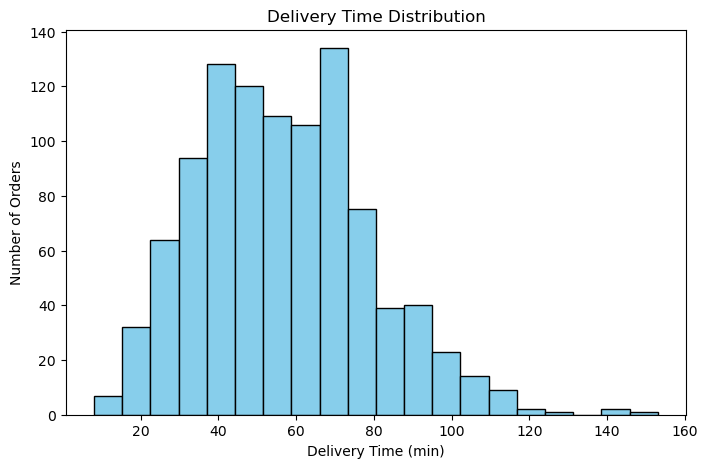

Average Delivery Time: 56.73 minutes
Minimum Delivery Time: 8
Maximum Delivery Time: 153


In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["Delivery_Time_min"], bins=20, color="skyblue", edgecolor="black")
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Number of Orders")
plt.show()

print("Average Delivery Time:", round(df["Delivery_Time_min"].mean(), 2), "minutes")
print("Minimum Delivery Time:", df["Delivery_Time_min"].min())
print("Maximum Delivery Time:", df["Delivery_Time_min"].max())

**CHECK DIATANCE VS DELIVERY TIME**

**In this step, I checked how delivery distance affects delivery time.
This helps us understand whether longer distances cause more delay**

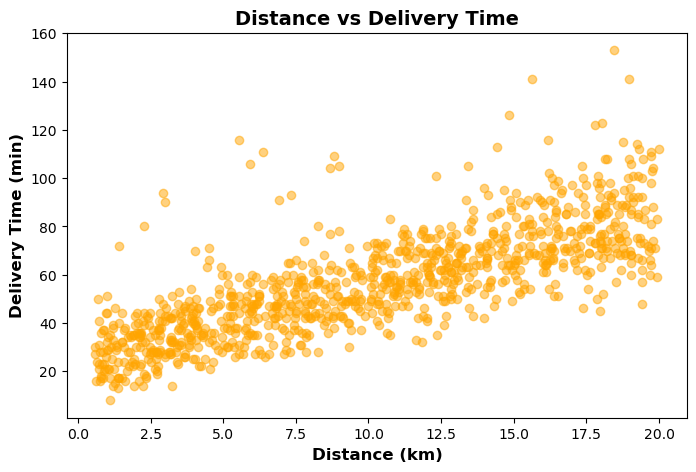

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["Distance_km"], df["Delivery_Time_min"], color="orange", alpha=0.5)

plt.title("Distance vs Delivery Time", fontsize=14, fontweight='bold')
plt.xlabel("Distance (km)", fontsize=12, fontweight='bold')
plt.ylabel("Delivery Time (min)", fontsize=12, fontweight='bold')

plt.show()

**CHECK WHEATHER IMPACT**

**In this step, I analyzed the average delivery time for different weather**
**conditions to understand the impact of weather on delivery performance.**

In [33]:
weather_avg = df.groupby("Weather")["Delivery_Time_min"].mean()
print(weather_avg)

Weather
Clear    53.150000
Foggy    59.466019
Rainy    59.794118
Snowy    67.113402
Windy    55.458333
Name: Delivery_Time_min, dtype: float64


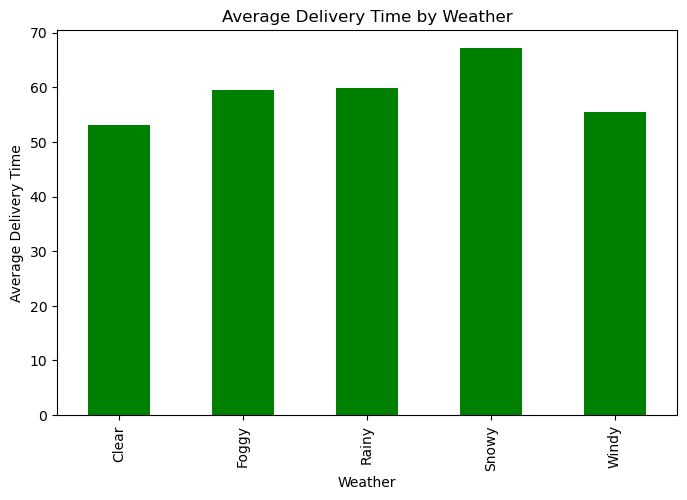

In [34]:
weather_avg.plot(kind="bar", color="green", figsize=(8,5))
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time")
plt.show()

**CHECK TRAFFIC IMPACT**

**In this step, I analyzed how traffic level affects delivery time.
This helps identify whether high traffic causes delivery delays.**

In [35]:
traffic_avg = df.groupby("Traffic_Level")["Delivery_Time_min"].mean()
print(traffic_avg)

Traffic_Level
High      64.807107
Low       52.885117
Medium    56.452381
Name: Delivery_Time_min, dtype: float64


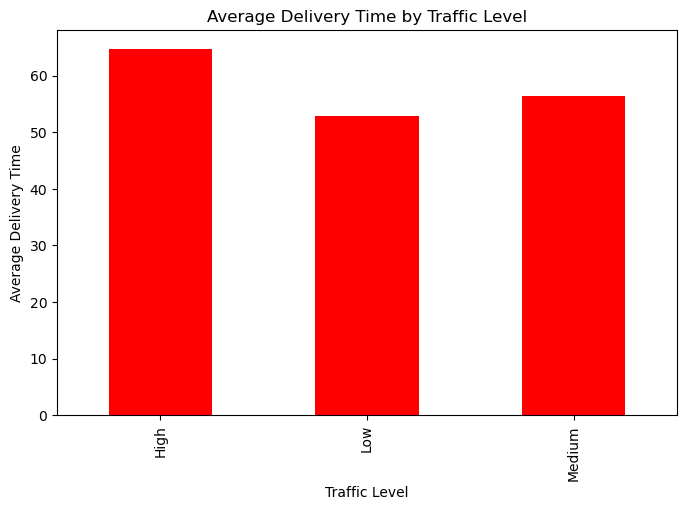

In [36]:
traffic_avg.plot(kind="bar", color="red", figsize=(8,5))
plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time")
plt.show()


**CHECK VEHICLE TYPE IMPACT**

**In this step, I compared delivery time across different vehicle types to check which vehicle performs better.**

In [37]:
vehicle_avg = df.groupby("Vehicle_Type")["Delivery_Time_min"].mean()
print(vehicle_avg)

Vehicle_Type
Bike       56.574553
Car        58.200000
Scooter    56.046358
Name: Delivery_Time_min, dtype: float64


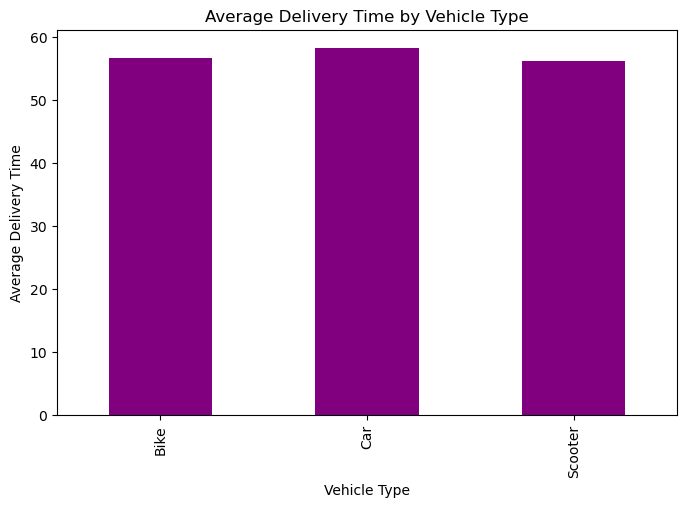

In [38]:
vehicle_avg.plot(kind="bar", color="purple", figsize=(8,5))
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time")
plt.show()

**Check Courier Experience Impact**

**In this step, I analyzed whether courier experience has any impact on delivery performance.**

In [39]:
exp_avg = df.groupby("Courier_Experience_yrs")["Delivery_Time_min"].mean()
print(exp_avg)

Courier_Experience_yrs
0.0    60.230769
1.0    60.485981
2.0    54.373737
3.0    60.275000
4.0    59.595745
5.0    54.300000
6.0    56.541284
7.0    54.846154
8.0    53.990099
9.0    54.157407
Name: Delivery_Time_min, dtype: float64


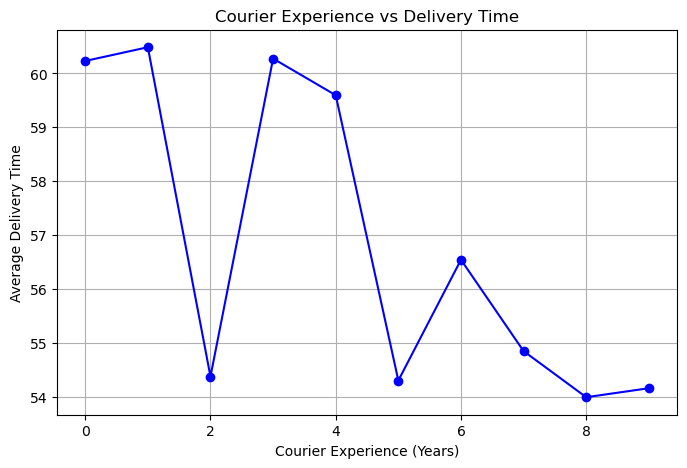

In [45]:
plt.figure(figsize=(8,5))
plt.plot(exp_avg.index, exp_avg.values, marker="o", color="blue")
plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Average Delivery Time")
plt.grid(True)
plt.show()

**Correlation Analysis**

**In this step, I analyzed the relationship between numerical variables and delivery time.
This helped me identify which factor has the strongest impact on delivery delay**

In [41]:
corr = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]].corr()
print(corr)

                        Distance_km  Preparation_Time_min  \
Distance_km                1.000000             -0.009037   
Preparation_Time_min      -0.009037              1.000000   
Courier_Experience_yrs    -0.007534             -0.030842   
Delivery_Time_min          0.780998              0.307350   

                        Courier_Experience_yrs  Delivery_Time_min  
Distance_km                          -0.007534           0.780998  
Preparation_Time_min                 -0.030842           0.307350  
Courier_Experience_yrs                1.000000          -0.089111  
Delivery_Time_min                    -0.089111           1.000000  


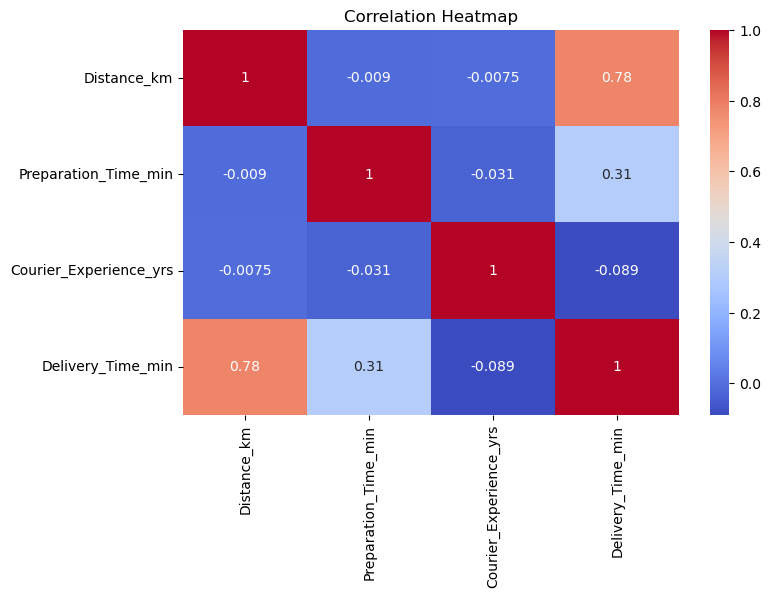

In [42]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**FINAL STEP : FINAL INSIGHTS**

**In this step, I summarized the key findings from the analysis.**

In [43]:
print("Final Insights:")
print("1. Distance has a strong impact on delivery time.")
print("2. High traffic increases delivery delay.")
print("3. Bad weather conditions increase delivery time.")
print("4. Courier experience helps improve delivery performance.")
print("5. Preparation time also affects the final delivery time.")

Final Insights:
1. Distance has a strong impact on delivery time.
2. High traffic increases delivery delay.
3. Bad weather conditions increase delivery time.
4. Courier experience helps improve delivery performance.
5. Preparation time also affects the final delivery time.


**BUSINESS IMPACT**

**This analysis helps the business improve food delivery operations.

- The company can assign the nearest courier to reduce delay.
- It can use route optimization for faster delivery.
- During high traffic hours, it can deploy more delivery agents.
- During bad weather, it can alert customers with realistic ETA.
- Experienced couriers can be assigned to long-distance orders**
-